In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile
from skimage.measure import regionprops_table

# ----------------------- CONFIG -----------------------
folders_to_read = [
    Path(r"Z:\Jorge\SPACEFISH_analysis\2026\v115-3Drep2-0101-indinuc"),
    Path(r"Z:\Jorge\SPACEFISH_analysis\2026\v115-vascu-0101-indinuc"),
]
subfolders_to_skip = [
    Path(r"Z:\Jorge\SPACEFISH_analysis\2026\v115-3Drep2-0101-indinuc\results\dev1_2_6h"),
]
output_dir = Path(r"c:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish")
# ------------------------------------------------------

output_dir.mkdir(parents=True, exist_ok=True)
skip_resolved = {p.resolve() for p in subfolders_to_skip}


def is_skipped(folder: Path) -> bool:
    rp = folder.resolve()
    return rp in skip_resolved or any(parent in skip_resolved for parent in rp.parents)


def find_image_folders(roots):
    """An 'image folder' is any folder containing a *count_table*.csv."""
    found = []
    for root in roots:
        for csv in root.rglob("*count_table*.csv"):
            folder = csv.parent
            if is_skipped(folder):
                print(f"[SKIP - excluded] {folder}")
                continue
            found.append(folder)
    return sorted(set(found))


def centroids_from_mask(mask: np.ndarray):
    """Return (props_df, (Xmax, Ymax, Zmax)). Mask assumed (Z, Y, X) if 3D."""
    mask = np.squeeze(mask)
    props = pd.DataFrame(regionprops_table(mask, properties=("label", "centroid")))
    if mask.ndim == 3:
        props = props.rename(columns={
            "centroid-0": "nucleus_centroid_z",
            "centroid-1": "nucleus_centroid_y",
            "centroid-2": "nucleus_centroid_x",
        })
        zmax, ymax, xmax = mask.shape
    else:  # 2D fallback
        props = props.rename(columns={
            "centroid-0": "nucleus_centroid_y",
            "centroid-1": "nucleus_centroid_x",
        })
        props["nucleus_centroid_z"] = np.nan
        ymax, xmax = mask.shape
        zmax = 1
    return props, (int(xmax), int(ymax), int(zmax))



In [3]:
import random

# ---- SANITY CHECK: does nucleus_xyz.csv match centroids derived from seg_mask? ----
_check_cache = {}  # folder.name -> merged dataframe (so we don't reload masks)

def check_one(folder: Path):
    seg_path = next(iter(folder.glob("*seg_mask*.tif")), None)
    xyz_path = folder / "nucleus_xyz.csv"
    if seg_path is None or not xyz_path.exists():
        return None

    mask = np.squeeze(tifffile.imread(str(seg_path)))
    props, (xmax, ymax, zmax) = centroids_from_mask(mask)
    props = props.rename(columns={"label": "nucleus"})

    xyz = pd.read_csv(xyz_path).rename(columns={"ID": "nucleus"})
    m = props.merge(xyz, on="nucleus", how="inner")
    _check_cache[folder.name] = m.copy()

    # direct mapping (centroid_x vs xyz.x, etc.)
    dx = (m["nucleus_centroid_x"] - m["x"]).abs()
    dy = (m["nucleus_centroid_y"] - m["y"]).abs()
    dz = (m["nucleus_centroid_z"] - m["z"]).abs()
    # swapped mapping (centroid_x vs xyz.y, centroid_y vs xyz.x)
    dx_s = (m["nucleus_centroid_x"] - m["y"]).abs()
    dy_s = (m["nucleus_centroid_y"] - m["x"]).abs()
    return {
        "folder": folder.name,
        "mask_shape_ZYX": mask.shape,
        "n_matched": len(m),
        "max_dx": dx.max(), "max_dy": dy.max(), "max_dz": dz.max(),
        "mean_dx": dx.mean(), "mean_dy": dy.mean(), "mean_dz": dz.mean(),
        "max_dx_swap": dx_s.max(), "max_dy_swap": dy_s.max(),
        "mean_dx_swap": dx_s.mean(), "mean_dy_swap": dy_s.mean(),
    }

_folders = find_image_folders(folders_to_read)
_sample = random.sample(_folders, min(4, len(_folders)))
report = pd.DataFrame([r for f in _sample if (r := check_one(f))])
report


[SKIP - excluded] Z:\Jorge\SPACEFISH_analysis\2026\v115-3Drep2-0101-indinuc\results\dev1_2_6h


,folder,mask_shape_ZYX,n_matched,max_dx,max_dy,max_dz,mean_dx,mean_dy,mean_dz,max_dx_swap,max_dy_swap,mean_dx_swap,mean_dy_swap
0,dev9_4_day4,"(126, 3930, 3933)",645,3492.937532,3494.945576,2.867423,1267.824355,1268.540583,1.053064,6.464122,8.371596,1.111194,1.253711
1,dev7_3_day1_large,"(252, 5799, 5811)",2530,5650.532523,5646.022329,4.376836,1968.872291,1968.847870,1.056238,13.102953,8.541668,1.104334,1.194437
2,dev8_3_day4,"(126, 3906, 3930)",815,3810.249745,3813.077528,4.025384,1331.143630,1331.309071,1.072021,5.857744,11.352594,1.151760,1.177036
3,dev8_2_day1_noamp,"(126, 2067, 3873)",266,3506.476248,3508.951240,3.864559,1201.478779,1202.727941,1.073848,6.346118,6.608980,1.122268,1.140993


In [4]:
def source_root_name(folder: Path) -> str:
    """Name of the top-level root in folders_to_read that contains this folder."""
    rp = folder.resolve()
    for root in folders_to_read:
        rr = root.resolve()
        if rp == rr or rr in rp.parents:
            return root.name
    return "UNKNOWN"


def mask_extent(seg_path: Path):
    """Read only the array shape (no pixel data) -> (Xmax, Ymax, Zmax)."""
    shape = tifffile.TiffFile(str(seg_path)).series[0].shape
    shape = tuple(s for s in shape if s > 1)  # drop singleton axes
    if len(shape) == 3:
        zmax, ymax, xmax = shape
    else:
        ymax, xmax = shape
        zmax = 1
    return int(xmax), int(ymax), int(zmax)


all_tables = []
image_folders = find_image_folders(folders_to_read)
print(f"Found {len(image_folders)} candidate image folders.\n")

for folder in image_folders:
    count_csv = next(iter(folder.glob("*count_table*.csv")), None)
    seg_path = next(iter(folder.glob("*seg_mask*.tif")), None)
    xyz_path = folder / "nucleus_xyz.csv"

    if seg_path is None:
        print(f"[SKIP - no seg_mask] {folder}")
        continue
    if not xyz_path.exists():
        print(f"[SKIP - no nucleus_xyz.csv] {folder}")
        continue

    df = pd.read_csv(count_csv)

    # Centroids from nucleus_xyz.csv (fast). NOTE: validated x<->y swap vs seg_mask.
    xyz = pd.read_csv(xyz_path).rename(columns={
        "ID": "nucleus",
        "x": "nucleus_centroid_y",   # csv 'x' is image row (Y)
        "y": "nucleus_centroid_x",   # csv 'y' is image column (X)
        "z": "nucleus_centroid_z",
    })[["nucleus", "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z"]]
    df = df.merge(xyz, on="nucleus", how="left")

    # Extent from mask header only (no full load).
    xmax, ymax, zmax = mask_extent(seg_path)
    df["Xmax"], df["Ymax"], df["Zmax"] = xmax, ymax, zmax

    # Provenance: which root folder this image came from.
    df.insert(0, "source_folder", source_root_name(folder))

    out_name = f"{folder.name}_count_table_xyz.csv"
    df.to_csv(output_dir / out_name, index=False)
    all_tables.append(df)
    n_missing = df["nucleus_centroid_x"].isna().sum()
    print(f"[OK] {folder.name} [{df['source_folder'].iloc[0]}]: "
          f"{len(df)} nuclei ({n_missing} missing centroid), extent (X,Y,Z)=({xmax},{ymax},{zmax})")

# Concatenate every nucleus from every image into one table.
if all_tables:
    combined = pd.concat(all_tables, ignore_index=True)
    combined.to_csv(output_dir / "all_nuclei.csv", index=False)
    print(f"\nCombined table: {combined.shape[0]} nuclei x {combined.shape[1]} columns")
    print(f"Saved -> {output_dir / 'all_nuclei.csv'}")
else:
    print("\nNo folders produced output.")


[SKIP - excluded] Z:\Jorge\SPACEFISH_analysis\2026\v115-3Drep2-0101-indinuc\results\dev1_2_6h
Found 24 candidate image folders.

[OK] dev1_3_6h [v115-3Drep2-0101-indinuc]: 1000 nuclei (0 missing centroid), extent (X,Y,Z)=(3933,3945,126)
[SKIP - no nucleus_xyz.csv] Z:\Jorge\SPACEFISH_analysis\2026\v115-3Drep2-0101-indinuc\results\dev1_4_6h
[OK] dev3_2_day1 [v115-3Drep2-0101-indinuc]: 944 nuclei (0 missing centroid), extent (X,Y,Z)=(4059,4074,126)
[OK] dev3_3_day1 [v115-3Drep2-0101-indinuc]: 1032 nuclei (0 missing centroid), extent (X,Y,Z)=(3945,3942,126)
[OK] dev6_2_day2 [v115-3Drep2-0101-indinuc]: 862 nuclei (0 missing centroid), extent (X,Y,Z)=(3930,3978,126)
[OK] dev6_3_day2 [v115-3Drep2-0101-indinuc]: 856 nuclei (0 missing centroid), extent (X,Y,Z)=(3948,3954,126)
[OK] dev6_4_day2 [v115-3Drep2-0101-indinuc]: 758 nuclei (0 missing centroid), extent (X,Y,Z)=(3936,3951,126)
[OK] dev8_2_day4 [v115-3Drep2-0101-indinuc]: 710 nuclei (0 missing centroid), extent (X,Y,Z)=(3936,3909,126)
[OK]

In [7]:
combined.head()

,source_folder,name,nucleus,CDH5,MMP1,COL1A1,KDR,VWF,PECAM1,VEGFA,...,FP4col12,FP4col13,FP4col14,FP4col15,nucleus_centroid_x,nucleus_centroid_y,nucleus_centroid_z,Xmax,Ymax,Zmax
0,v115-3Drep2-0101-indinuc,dev1_3_6h,1,0,0,0,0,0,0,1,...,0,0,0,0,3420.720565,1315.118849,24,3933,3945,126
1,v115-3Drep2-0101-indinuc,dev1_3_6h,2,1,0,0,0,1,1,0,...,0,0,0,0,3344.176875,1313.184155,23,3933,3945,126
2,v115-3Drep2-0101-indinuc,dev1_3_6h,3,0,0,0,0,2,0,0,...,0,0,0,0,3294.685265,1413.751726,23,3933,3945,126
3,v115-3Drep2-0101-indinuc,dev1_3_6h,4,0,0,0,0,0,0,0,...,0,0,0,0,3831.060972,1448.324364,24,3933,3945,126
4,v115-3Drep2-0101-indinuc,dev1_3_6h,5,2,0,0,0,0,0,0,...,0,0,0,0,1924.543792,1829.677652,28,3933,3945,126


,source_folder,name,nucleus,CDH5,MMP1,COL1A1,KDR,VWF,PECAM1,VEGFA,...,FP4col13,FP4col14,FP4col15,nucleus_centroid_x,nucleus_centroid_y,nucleus_centroid_z,Xmax,Ymax,Zmax,gene_ID
0,v115-3Drep2-0101-indinuc,dev1_3_6h,1,0,0,0,0,0,0,1,...,0,0,0,3420.720565,1315.118849,24,3933,3945,126,000000100000000000
1,v115-3Drep2-0101-indinuc,dev1_3_6h,2,1,0,0,0,1,1,0,...,0,0,0,3344.176875,1313.184155,23,3933,3945,126,100011000000100000
2,v115-3Drep2-0101-indinuc,dev1_3_6h,3,0,0,0,0,1,0,0,...,0,0,0,3294.685265,1413.751726,23,3933,3945,126,000020000002100000
3,v115-3Drep2-0101-indinuc,dev1_3_6h,4,0,0,0,0,0,0,0,...,0,0,0,3831.060972,1448.324364,24,3933,3945,126,000000000000000000
4,v115-3Drep2-0101-indinuc,dev1_3_6h,5,1,0,0,0,0,0,0,...,0,0,0,1924.543792,1829.677652,28,3933,3945,126,200000000000000000


In [11]:
gene_columns = [col for col in combined.columns if col not in {"name", "source_folder", "nucleus", "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z", "Xmax", "Ymax", "Zmax"}]
print(f"Gene columns: {gene_columns}")
fp_columns = [col for col in gene_columns if col.startswith("FP")]
print(f"FP columns: {fp_columns}")
true_gene_columns = [col for col in gene_columns if not col.startswith("FP")]
print(f"True gene columns: {true_gene_columns}")

Gene columns: ['CDH5', 'MMP1', 'COL1A1', 'KDR', 'VWF', 'PECAM1', 'VEGFA', 'DLL4', 'ITGA6', 'SEMA3F', 'JAG1', 'FLT1', 'PDGFB', 'COL1A2', 'APLN', 'PDGFRB', 'ANGPT2', 'ICAM1', 'FP2col1', 'FP2col2', 'FP2col3', 'FP3col1', 'FP3col2', 'FP3col3', 'FP3col4', 'FP3col5', 'FP3col6', 'FP3col7', 'FP3col8', 'FP3col9', 'FP3col10', 'FP3col11', 'FP3col12', 'FP3col13', 'FP3col14', 'FP3col15', 'FP3col16', 'FP3col17', 'FP3col18', 'FP3col19', 'FP3col20', 'FP4col1', 'FP4col2', 'FP4col3', 'FP4col4', 'FP4col5', 'FP4col6', 'FP4col7', 'FP4col8', 'FP4col9', 'FP4col10', 'FP4col11', 'FP4col12', 'FP4col13', 'FP4col14', 'FP4col15']
FP columns: ['FP2col1', 'FP2col2', 'FP2col3', 'FP3col1', 'FP3col2', 'FP3col3', 'FP3col4', 'FP3col5', 'FP3col6', 'FP3col7', 'FP3col8', 'FP3col9', 'FP3col10', 'FP3col11', 'FP3col12', 'FP3col13', 'FP3col14', 'FP3col15', 'FP3col16', 'FP3col17', 'FP3col18', 'FP3col19', 'FP3col20', 'FP4col1', 'FP4col2', 'FP4col3', 'FP4col4', 'FP4col5', 'FP4col6', 'FP4col7', 'FP4col8', 'FP4col9', 'FP4col10', 'FP4

In [23]:
combined_binary = combined.copy()
combined_binary[true_gene_columns] = combined[true_gene_columns].replace({2: 1}) 
combined_binary.head()

,source_folder,name,nucleus,CDH5,MMP1,COL1A1,KDR,VWF,PECAM1,VEGFA,...,FP4col13,FP4col14,FP4col15,nucleus_centroid_x,nucleus_centroid_y,nucleus_centroid_z,Xmax,Ymax,Zmax,gene_ID
0,v115-3Drep2-0101-indinuc,dev1_3_6h,1,0,0,0,0,0,0,1,...,0,0,0,3420.720565,1315.118849,24,3933,3945,126,000000100000000000
1,v115-3Drep2-0101-indinuc,dev1_3_6h,2,1,0,0,0,1,1,0,...,0,0,0,3344.176875,1313.184155,23,3933,3945,126,100011000000100000
2,v115-3Drep2-0101-indinuc,dev1_3_6h,3,0,0,0,0,1,0,0,...,0,0,0,3294.685265,1413.751726,23,3933,3945,126,000020000002100000
3,v115-3Drep2-0101-indinuc,dev1_3_6h,4,0,0,0,0,0,0,0,...,0,0,0,3831.060972,1448.324364,24,3933,3945,126,000000000000000000
4,v115-3Drep2-0101-indinuc,dev1_3_6h,5,1,0,0,0,0,0,0,...,0,0,0,1924.543792,1829.677652,28,3933,3945,126,200000000000000000


In [24]:
combined["gene_ID"] = combined[true_gene_columns].astype(str).agg(''.join, axis=1)
combined_binary["gene_ID"] = combined_binary[true_gene_columns].astype(str).agg(''.join, axis=1)

combined.head()

,source_folder,name,nucleus,CDH5,MMP1,COL1A1,KDR,VWF,PECAM1,VEGFA,...,FP4col13,FP4col14,FP4col15,nucleus_centroid_x,nucleus_centroid_y,nucleus_centroid_z,Xmax,Ymax,Zmax,gene_ID
0,v115-3Drep2-0101-indinuc,dev1_3_6h,1,0,0,0,0,0,0,1,...,0,0,0,3420.720565,1315.118849,24,3933,3945,126,000000100000000000
1,v115-3Drep2-0101-indinuc,dev1_3_6h,2,1,0,0,0,1,1,0,...,0,0,0,3344.176875,1313.184155,23,3933,3945,126,100011000000100000
2,v115-3Drep2-0101-indinuc,dev1_3_6h,3,0,0,0,0,2,0,0,...,0,0,0,3294.685265,1413.751726,23,3933,3945,126,000020000002100000
3,v115-3Drep2-0101-indinuc,dev1_3_6h,4,0,0,0,0,0,0,0,...,0,0,0,3831.060972,1448.324364,24,3933,3945,126,000000000000000000
4,v115-3Drep2-0101-indinuc,dev1_3_6h,5,2,0,0,0,0,0,0,...,0,0,0,1924.543792,1829.677652,28,3933,3945,126,200000000000000000


In [25]:
len(combined["gene_ID"].unique()), len(combined_binary["gene_ID"].unique())

(3577, 2418)

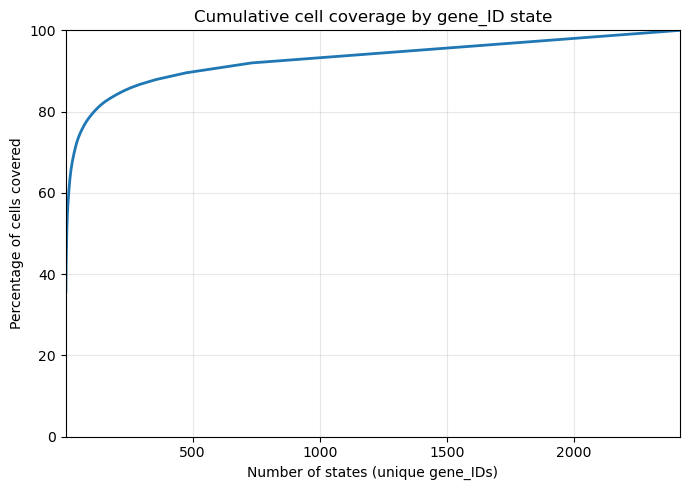

,gene_ID,n_cells,n_states,pct_cells_covered
0,000000000000000000,7516,1,35.766632
1,100000000000000000,1462,2,42.723898
2,000000100000000000,714,3,46.121633
3,000100000000000000,682,4,49.367089
4,100100000000000000,459,5,51.551347
...,...,...,...,...
95,100001010000000000,17,96,78.799848
96,100000100100000000,17,97,78.880746
97,300001000000000000,17,98,78.961645
98,100110000000100000,16,99,79.037784


In [26]:
import matplotlib.pyplot as plt

state_counts = combined_binary["gene_ID"].value_counts()
coverage = (
    state_counts.rename_axis("gene_ID")
    .reset_index(name="n_cells")
)
coverage["n_states"] = np.arange(1, len(coverage) + 1)
coverage["pct_cells_covered"] = 100 * coverage["n_cells"].cumsum() / coverage["n_cells"].sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(coverage["n_states"], coverage["pct_cells_covered"], linewidth=2)
ax.set_xlabel("Number of states (unique gene_IDs)")
ax.set_ylabel("Percentage of cells covered")
ax.set_title("Cumulative cell coverage by gene_ID state")
ax.set_xlim(1, len(coverage))
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

coverage.head(100)


In [27]:
coverage.to_csv(output_dir / "gene_ID_coverage_binaryonly.csv", index=False)

In [29]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster

# ---------- Parameters ----------
min_cells_per_state = 3
hamming_threshold = 0.20  # states within this fractional bit-difference are grouped

# ---------- Build true-gene-only binary state matrix ----------
# Prefer existing true_gene_columns from above; otherwise infer by excluding metadata and FP columns.
if "true_gene_columns" not in globals() or not true_gene_columns:
    metadata_cols = {
        "name", "source_folder", "nucleus",
        "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z",
        "Xmax", "Ymax", "Zmax", "gene_ID"
    }
    candidate_cols = [c for c in combined_binary.columns if c not in metadata_cols]
    true_gene_columns = [c for c in candidate_cols if not str(c).startswith("FP")]

# Force binary states: any nonzero count -> 1
state_matrix = (combined_binary[true_gene_columns].fillna(0).astype(float) > 0).astype(np.uint8)
state_key = state_matrix.astype(str).agg("".join, axis=1)

state_counts = state_key.value_counts()
keep_states = state_counts[state_counts >= min_cells_per_state].index

mask_keep = state_key.isin(keep_states)
filtered_cells = combined_binary.loc[mask_keep].copy()
filtered_states = state_key[mask_keep]

print(f"Total cells: {len(combined_binary):,}")
print(f"Unique binary states (all): {state_counts.size:,}")
print(f"Retained binary states (>= {min_cells_per_state} cells): {len(keep_states):,}")
print(f"Cells retained after filtering: {len(filtered_cells):,} ({100*len(filtered_cells)/len(combined_binary):.1f}%)")

# ---------- Unique retained states + frequencies ----------
state_summary = (
    filtered_states.value_counts()
    .rename_axis("gene_ID")
    .reset_index(name="n_cells")
)

state_vectors = np.array([[int(ch) for ch in s] for s in state_summary["gene_ID"]], dtype=np.uint8)

# ---------- Hamming-distance clustering on retained unique states ----------
if len(state_summary) == 1:
    state_summary["cluster_id"] = 1
    state_summary["nearest_neighbor_hamming"] = np.nan
else:
    dist_condensed = pdist(state_vectors, metric="hamming")
    Z = linkage(dist_condensed, method="average")
    state_summary["cluster_id"] = fcluster(Z, t=hamming_threshold, criterion="distance")

    dist_matrix = squareform(dist_condensed)
    np.fill_diagonal(dist_matrix, np.inf)
    state_summary["nearest_neighbor_hamming"] = dist_matrix.min(axis=1)

cluster_summary = (
    state_summary.groupby("cluster_id", as_index=False)
    .agg(
        n_states=("gene_ID", "size"),
        n_cells=("n_cells", "sum"),
        mean_nn_hamming=("nearest_neighbor_hamming", "mean"),
    )
    .sort_values(["n_cells", "n_states"], ascending=False)
)
cluster_summary["pct_cells_retained"] = 100 * cluster_summary["n_cells"] / cluster_summary["n_cells"].sum()

print("\nTop clusters by retained cell coverage:")
display(cluster_summary.head(20))

print("\nTop retained states with assigned clusters:")
display(state_summary.sort_values("n_cells", ascending=False).head(30))

# Optional exports for downstream review
state_summary.to_csv(output_dir / "gene_state_summary_binary_min3cells_hamming_clusters.csv", index=False)
cluster_summary.to_csv(output_dir / "gene_state_cluster_summary_binary_min3cells.csv", index=False)

print("\nSaved:")
print(output_dir / "gene_state_summary_binary_min3cells_hamming_clusters.csv")
print(output_dir / "gene_state_cluster_summary_binary_min3cells.csv")


Total cells: 21,014
Unique binary states (all): 1,762
Retained binary states (>= 3 cells): 468
Cells retained after filtering: 19,495 (92.8%)

Top clusters by retained cell coverage:


,cluster_id,n_states,n_cells,mean_nn_hamming,pct_cells_retained
19,20,34,13358,0.055556,68.520133
14,15,31,997,0.055556,5.114132
18,19,21,687,0.055556,3.523981
8,9,32,673,0.055556,3.452167
2,3,28,658,0.055556,3.375224
16,17,33,449,0.055556,2.303155
0,1,33,439,0.055556,2.251859
5,6,41,438,0.055556,2.246730
9,10,37,354,0.055556,1.815850
17,18,23,284,0.055556,1.456784



Top retained states with assigned clusters:


,gene_ID,n_cells,cluster_id,nearest_neighbor_hamming
0,000000000000000000,7516,20,0.055556
1,100000000000000000,1545,20,0.055556
2,000000100000000000,734,20,0.055556
3,000100000000000000,685,20,0.055556
4,100100000000000000,505,20,0.055556
5,000010000000000000,408,20,0.055556
6,100000100000000000,341,20,0.055556
7,100010000000000000,327,20,0.055556
8,100100100000000000,269,20,0.055556
9,100000010000000000,221,19,0.055556



Saved:
c:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\gene_state_summary_binary_min3cells_hamming_clusters.csv
c:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\gene_state_cluster_summary_binary_min3cells.csv
